# Masters in Data Science Scholarship Exam
**Candidate** - *Joseph Kuria Njau*

**Date** ; *12th May 2025*

## Objectives
**1.Identifying key demographic and socio-economic variables that explain the variance of the well-being index of galaxies.**

**2.Predicting future well-being index values for the validation dataset.**

### Step 1; Installing Pandas in this Jupyter Notebook

In [2]:
!pip install pandas

### Step 2; Installing the most essential libraries for data analysis and visualization

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Step 3; Loading both the training and validation data sets from the downloads folder in the desktop

In [49]:
train_df = pd.read_csv('Downloads/Train_data.csv')
validation_df = pd.read_csv('Downloads/Validation.csv')


### Step 4; Displaying the first 5 rows of both the training and validation data to be able to get a quick preview of the dataset

In [50]:
train_df.head()

,ID,galactic year,galaxy,existence expectancy index,existence expectancy at birth,Gross income per capita,Income Index,Expected years of education (galactic years),Mean years of education (galactic years),Intergalactic Development Index (IDI),...,"Intergalactic Development Index (IDI), female","Intergalactic Development Index (IDI), male",Gender Development Index (GDI),"Intergalactic Development Index (IDI), female, Rank","Intergalactic Development Index (IDI), male, Rank",Adjusted net savings,"Creature Immunodeficiency Disease prevalence, adult (% ages 15-49), total",Private galaxy capital flows (% of GGP),Gender Inequality Index (GII),Well-Being Index
0,10065,1002001,Antlia B,0.624015,56.397241,17649.87156,0.458599,7.857841,5.196527,0.507534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041404
1,10087,999000,KKH 11 (ZOAG G135.74-04.53),0.970048,80.924094,11409.94296,0.757218,15.869798,13.065734,0.807108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098777
2,10141,993012,Leo IV Dwarf,0.995540,82.441006,58774.29343,1.032429,17.545117,11.399711,0.973684,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.200747
3,10168,995006,NGC 185,1.004362,75.635986,34960.41911,0.707776,13.578086,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.546539,NaN,0.562809,0.067170
4,10201,996004,Grus I,1.050627,83.412540,17073.45121,0.951402,13.518157,11.749071,0.965452,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.078351


In [51]:
validation_df.head()

,ID,galactic year,galaxy,existence expectancy index,existence expectancy at birth,Gross income per capita,Income Index,Expected years of education (galactic years),Mean years of education (galactic years),Intergalactic Development Index (IDI),...,"Intergalactic Development Index (IDI), female","Intergalactic Development Index (IDI), male",Gender Development Index (GDI),"Intergalactic Development Index (IDI), female, Rank","Intergalactic Development Index (IDI), male, Rank",Adjusted net savings,"Creature Immunodeficiency Disease prevalence, adult (% ages 15-49), total",Private galaxy capital flows (% of GGP),Gender Inequality Index (GII),Predicted Well-Being Index
0,886447,1004004,Andromeda Galaxy (M31),0.803915,82.718434,17299.57148,0.691448,16.083635,11.282011,0.715746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,687564,1005006,Andromeda Galaxy (M31),0.860011,73.682279,24971.71631,0.669550,12.858577,10.493260,0.727915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,494935,1006009,Andromeda Galaxy (M31),0.810644,68.456526,15943.82977,0.766118,14.236676,9.962169,0.757072,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,378919,1015056,Andromeda Galaxy (M31),0.837170,68.742404,20952.63665,0.757196,14.281498,10.329880,0.759207,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.753738,NaN,NaN
4,421878,1004004,Andromeda I,0.749034,72.093220,30068.14043,0.641228,12.510524,7.132999,0.673619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 5; Checking the shape of the two data sets and getting to see the summary statistics

In [52]:
print(f"Training data shape: {train_df.shape}")
train_df.describe()

Training data shape: (3097, 81)


,ID,galactic year,existence expectancy index,existence expectancy at birth,Gross income per capita,Income Index,Expected years of education (galactic years),Mean years of education (galactic years),Intergalactic Development Index (IDI),Education Index,...,"Intergalactic Development Index (IDI), female","Intergalactic Development Index (IDI), male",Gender Development Index (GDI),"Intergalactic Development Index (IDI), female, Rank","Intergalactic Development Index (IDI), male, Rank",Adjusted net savings,"Creature Immunodeficiency Disease prevalence, adult (% ages 15-49), total",Private galaxy capital flows (% of GGP),Gender Inequality Index (GII),Well-Being Index
count,3097.000000,3.097000e+03,3096.000000,3096.000000,3069.000000,3069.000000,2968.000000,2742.000000,2716.000000,2716.000000,...,389.000000,388.000000,387.000000,379.000000,378.000000,443.000000,516.000000,379.000000,357.000000,3097.000000
mean,157659.407168,9.984641e+05,0.863193,76.197777,31175.236021,0.819082,14.442264,10.058239,0.793514,0.731124,...,0.793432,0.819060,0.996730,115.538727,114.562123,21.017915,6.206214,23.850270,0.632819,0.082724
std,230716.474733,5.417848e+03,0.164595,10.539559,18574.375226,0.194201,3.622899,3.265167,0.176389,0.198845,...,0.189934,0.163253,0.095212,43.340795,43.560836,13.740650,4.564555,19.875983,0.204801,0.056014
min,10065.000000,9.900250e+05,0.227890,34.244062,-126.906521,0.292001,3.799663,1.928166,0.273684,0.189874,...,0.305733,0.369519,0.465177,23.540325,16.215151,-59.118669,-1.192011,-207.979859,0.168476,0.031477
25%,38554.000000,9.940090e+05,0.749559,69.055828,19876.218060,0.672132,12.307716,7.482265,0.658223,0.582499,...,0.664505,0.699687,0.945058,78.452882,78.285805,15.156311,3.986965,17.229769,0.469759,0.049195
50%,67570.000000,9.980010e+05,0.899075,78.482889,26058.342360,0.821124,14.700321,10.129151,0.813372,0.748034,...,0.806885,0.829617,1.022518,116.789180,114.481115,21.427986,5.148086,24.337553,0.658255,0.058864
75%,95992.000000,1.003002e+06,0.985961,84.135993,36351.451720,0.962507,16.845018,12.593958,0.926053,0.881367,...,0.939555,0.943167,1.061130,146.081475,149.009737,28.804728,6.536906,32.095384,0.793525,0.087992
max,998085.000000,1.011030e+06,1.204456,99.593905,132861.542800,1.361883,25.303770,19.057648,1.186909,1.209059,...,1.173616,1.160796,1.181230,217.500271,226.816039,61.903641,31.822114,95.941245,1.098439,0.379857


In [53]:
print (f"validation data structure: {validation_df.shape}")
validation_df.describe()

validation data structure: (720, 81)


,ID,galactic year,existence expectancy index,existence expectancy at birth,Gross income per capita,Income Index,Expected years of education (galactic years),Mean years of education (galactic years),Intergalactic Development Index (IDI),Education Index,...,"Intergalactic Development Index (IDI), female","Intergalactic Development Index (IDI), male",Gender Development Index (GDI),"Intergalactic Development Index (IDI), female, Rank","Intergalactic Development Index (IDI), male, Rank",Adjusted net savings,"Creature Immunodeficiency Disease prevalence, adult (% ages 15-49), total",Private galaxy capital flows (% of GGP),Gender Inequality Index (GII),Predicted Well-Being Index
count,720.000000,7.200000e+02,720.000000,720.000000,720.000000,720.000000,720.000000,717.000000,717.000000,717.000000,...,519.000000,519.000000,519.000000,506.000000,506.000000,465.000000,419.000000,490.000000,481.000000,0.0
mean,540575.762500,1.010517e+06,0.917042,79.691455,33855.573134,0.857504,15.943017,11.157837,0.847852,0.803626,...,0.847814,0.864749,1.017964,126.282768,125.302843,21.463226,6.727467,21.009808,0.574781,NaN
std,269355.612476,3.604656e+03,0.142546,9.501613,19373.363190,0.187758,3.291771,3.364369,0.167249,0.192099,...,0.177948,0.151680,0.078604,47.841923,48.761122,14.795516,5.102837,42.380597,0.202148,NaN
min,13606.000000,1.003002e+06,0.440532,49.560998,547.581752,0.344815,4.879459,2.434786,0.379682,0.331112,...,0.335959,0.415198,0.697446,23.224603,19.728138,-76.741414,0.118915,-735.186887,0.089092,NaN
25%,305458.500000,1.006009e+06,0.818822,73.587883,21838.681733,0.710716,13.767775,8.526625,0.722407,0.661265,...,0.718365,0.755680,0.976213,87.309330,85.210507,14.656609,4.340744,17.239932,0.403722,NaN
50%,538092.500000,1.011030e+06,0.941859,81.639046,28904.644175,0.870243,16.028013,11.331809,0.866130,0.804856,...,0.860671,0.887245,1.036309,125.214846,126.313303,22.777495,5.415610,24.667940,0.601721,NaN
75%,793178.500000,1.013042e+06,1.028266,87.023131,39838.010810,1.000857,18.157923,13.873499,0.967411,0.951526,...,0.987633,0.975993,1.074332,167.093367,163.690516,29.563771,7.009201,31.608334,0.736253,NaN
max,999488.000000,1.015056e+06,1.246908,100.210053,151072.683200,1.324914,26.955944,18.770633,1.232814,1.269625,...,1.237661,1.182746,1.167894,232.720847,233.915373,57.725873,36.538462,85.509692,1.033566,NaN


### Step 6; Checking for missing values in the training data set to understand which columns may need cleaning or imputation.

In [54]:
missing_values = train_df.isnull().sum()
missing_values[missing_values > 0]

existence expectancy index                                                      1
existence expectancy at birth                                                   1
Gross income per capita                                                        28
Income Index                                                                   28
Expected years of education (galactic years)                                  129
                                                                             ... 
Intergalactic Development Index (IDI), male, Rank                            2719
Adjusted net savings                                                         2654
Creature Immunodeficiency Disease prevalence, adult (% ages 15-49), total    2581
Private galaxy capital flows (% of GGP)                                      2718
Gender Inequality Index (GII)                                                2740
Length: 77, dtype: int64

### Step 7; Dropping columns with more than 50% missing values since they are majorly uninformative and are dropped to clean the dataset.

In [55]:
threshold = len(train_df) * 0.5
train_df = train_df.dropna(thresh=threshold, axis=1)

### Step 8; Checking the remaining columns with missing values after dropping columns with more than 50% missing values

In [56]:
missing_values = train_df.isnull().sum()
missing_values[missing_values > 0]

existence expectancy index                        1
existence expectancy at birth                     1
Gross income per capita                          28
Income Index                                     28
Expected years of education (galactic years)    129
Mean years of education (galactic years)        355
Intergalactic Development Index (IDI)           381
Education Index                                 381
Intergalactic Development Index (IDI), Rank     419
dtype: int64

### Step 9; Filling missing values with the mean of each respective column, a common and simple imputation technique for numeric data.

In [57]:
# Fill missing values with the mean
train_df['existence expectancy index'] = train_df['existence expectancy index'].fillna(train_df['existence expectancy index'].mean())
train_df['existence expectancy at birth'] = train_df['existence expectancy at birth'].fillna(train_df['existence expectancy at birth'].mean())
train_df['Gross income per capita'] = train_df['Gross income per capita'].fillna(train_df['Gross income per capita'].mean())
train_df['Income Index'] = train_df['Income Index'].fillna(train_df['Income Index'].mean())
train_df['Expected years of education (galactic years)'] = train_df['Expected years of education (galactic years)'].fillna(train_df['Expected years of education (galactic years)'].mean())
train_df['Mean years of education (galactic years)'] = train_df['Mean years of education (galactic years)'].fillna(train_df['Mean years of education (galactic years)'].mean())
train_df['Intergalactic Development Index (IDI)'] = train_df['Intergalactic Development Index (IDI)'].fillna(train_df['Intergalactic Development Index (IDI)'].mean())
train_df['Education Index'] = train_df['Education Index'].fillna(train_df['Education Index'].mean())
train_df['Intergalactic Development Index (IDI), Rank'] = train_df['Intergalactic Development Index (IDI), Rank'].fillna(train_df['Intergalactic Development Index (IDI), Rank'].mean())


### Step 10; Checking if there are any remaining missing values after filling missing values with the mean for their columns

In [58]:
# Check for any remaining missing values
print(train_df.isnull().sum().sum())

0


### Step 11; Plotting the distribution of the well-being index for the train data set to assess whether it is skewed and needs transformation.

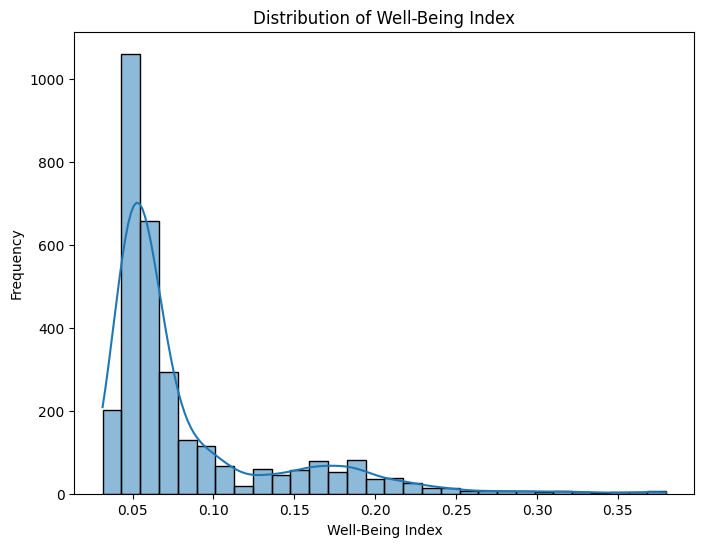

In [59]:
# Plot the distribution of the well-being index
plt.figure(figsize=(8, 6))
sns.histplot(train_df['Well-Being Index'], bins=30, kde=True)
plt.title('Distribution of Well-Being Index')
plt.xlabel('Well-Being Index')
plt.ylabel('Frequency')
plt.show()

### Step 12; Logging the well-being index for the well-being index to reduce skewness, which can improve model performance.

In [60]:
train_df['well_being_log'] = np.log(train_df['Well-Being Index'] + 1e-6)  # small value to avoid log(0)

### Step 13; Plotting the distribution of the logged values for the well-being index to ensure a more normal-like distribution.

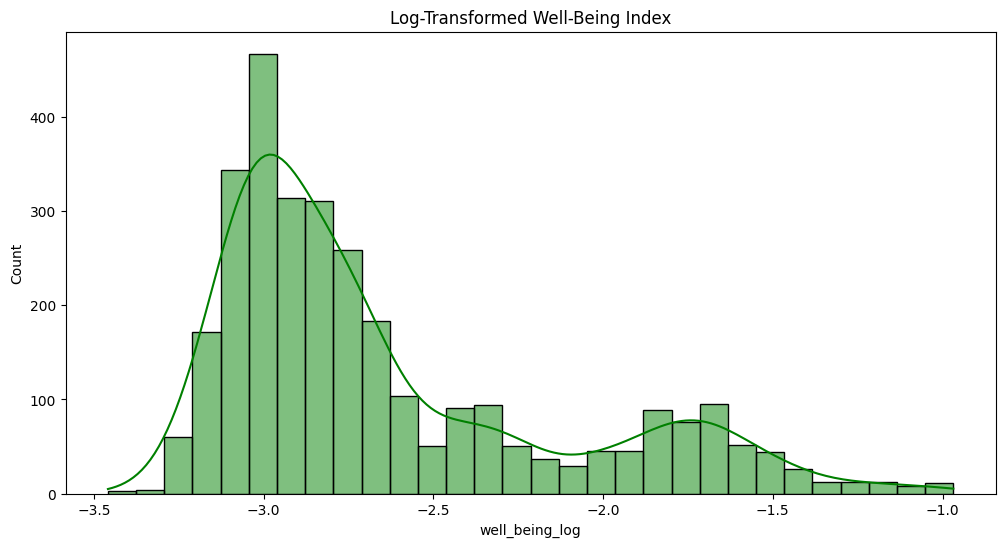

In [61]:
# Compare original vs transformed
plt.figure(figsize=(12, 6))
sns.histplot(train_df['well_being_log'], bins=30, kde=True, color='green')
plt.title('Log-Transformed Well-Being Index')
plt.show()

### Step 14; Correlation matrix for the numeric columns for the train data set and plotting a heatmap of the matrix to identify potentially strong predictors.

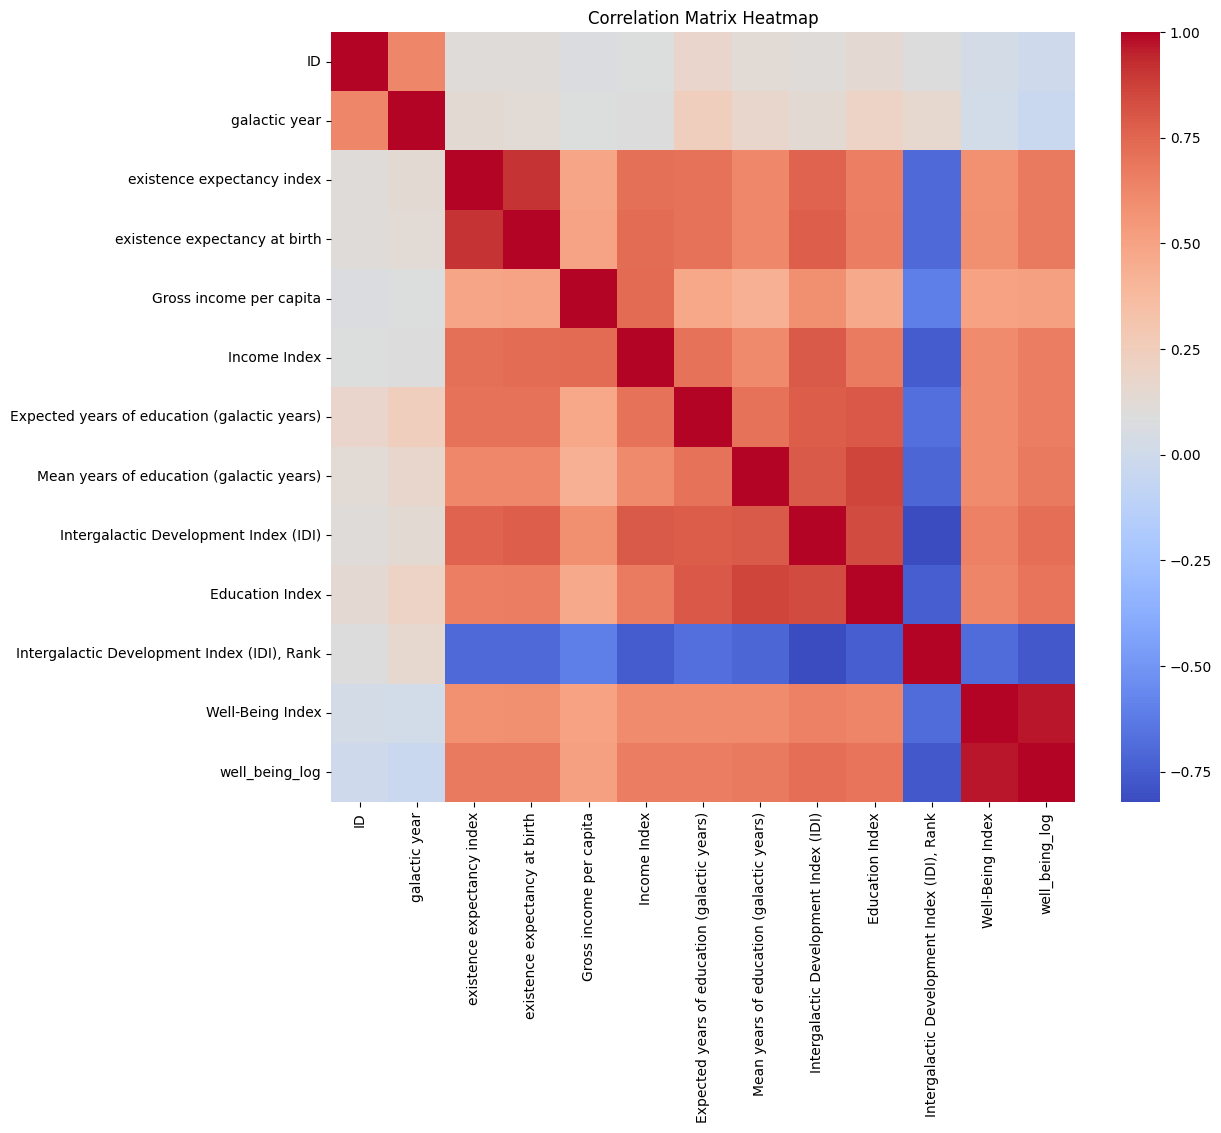

In [62]:
corr_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Step 15; Identifying columns with high correlation to the well-being index and the well-being log.
#### For the well being index as also seen in the correlation heat map above, Intergalactic Development Index Rank has a high negative correlation, Intergalagctic Development Index has a strong positive correlation closely followed by the education index and Expected years of education (galactic years).
#### For the well being log as also seen in the correlation heat map, Intergalactic Development Index (IDI) Rank has a high negative correlation while Intergalactic Development Index (IDI) has a strong positive correlation followed by Education Index and existence expectancy at birth. 

In [63]:
correlation_with_target = corr_matrix['Well-Being Index'].abs().sort_values(ascending=False)
top_features = correlation_with_target[1:11].index.tolist()  # Exclude the target itself
print("Top correlated features:", top_features)

Top correlated features: ['well_being_log', 'Intergalactic Development Index (IDI), Rank', 'Intergalactic Development Index (IDI)', 'Education Index', 'Expected years of education (galactic years)', 'Income Index', 'Mean years of education (galactic years)', 'existence expectancy at birth', 'existence expectancy index', 'Gross income per capita']


In [64]:
correlation_with_target = corr_matrix['well_being_log'].abs().sort_values(ascending=False)
top_features = correlation_with_target[1:11].index.tolist()  # Exclude the target itself
print("Top correlated features:", top_features)

Top correlated features: ['Well-Being Index', 'Intergalactic Development Index (IDI), Rank', 'Intergalactic Development Index (IDI)', 'Education Index', 'existence expectancy at birth', 'existence expectancy index', 'Mean years of education (galactic years)', 'Income Index', 'Expected years of education (galactic years)', 'Gross income per capita']


### Step 16; Data is split into features (X) and the target variable (y) so they can be used separately during modeling.

In [65]:
X = train_df.drop(columns=['Well-Being Index', 'well_being_log'])
y = train_df['well_being_log']
X_val = validation_df[X.columns]  # Ensure consistent feature columns

### Step 17; One-Hot Encode categorical variables if any into numeric format using one-hot encoding, necessary for machine learning models.

In [66]:
X_encoded = pd.get_dummies(X)
X_val_encoded = pd.get_dummies(X_val)

### Step 18; Aligning validation set columns to training set after encoding

In [67]:
X_val_encoded = X_val_encoded.reindex(columns=X_encoded.columns, fill_value=0)

### Step 19; Splitting training data to train and test subsets to evaluate our models before applying them to the validation set.

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [69]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Step 20: Defining models in pipelines with imputation

In [70]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

### Step 21; Training Model 1 - ***Linear Regression***

In [71]:


lr_pipeline.fit(X_train, y_train)
lr_preds_log = lr_pipeline.predict(X_test)
lr_preds = np.exp(lr_preds_log)  # Back-transform
lr_rmse = np.sqrt(mean_squared_error(np.exp(y_test), lr_preds))

### Step 22; Training Model 2 - ***Random Forest Regressor***

In [72]:
rf_pipeline.fit(X_train, y_train)
rf_preds_log = rf_pipeline.predict(X_test)
rf_preds = np.exp(rf_preds_log)  # Back-transform
rf_rmse = np.sqrt(mean_squared_error(np.exp(y_test), rf_preds))

### Step 23; Comparing the RMSE's for the two models and selecting the best model based on the lowest value of RMSE

In [74]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print(f"Linear Regression RMSE (log scale): {lr_rmse:.4f}")
print(f"Random Forest Regressor RMSE (log scale): {rf_rmse:.4f}")

if rf_rmse < lr_rmse:
    best_model = rf_model
    print("✅ Selected Model: Random Forest Regressor")
else:
    best_model = lr_model
    print("✅ Selected Model: Linear Regression")

Linear Regression RMSE (log scale): 0.0061
Random Forest Regressor RMSE (log scale): 0.0175
✅ Selected Model: Linear Regression


### Step 24; Preparing validation dataset by selecting the same columns/features used in training the model

In [75]:
X_val = validation_df[X.columns]  # Same columns used in training
X_val_encoded = pd.get_dummies(X_val)

### Step 25; Aligning validation features with training set

In [76]:
X_val_encoded = X_val_encoded.reindex(columns=X_encoded.columns, fill_value=0)

### Step 26; Predicting well-being index in validation set

In [77]:
validation_df['well_being_log'] = lr_pipeline.predict(X_val_encoded)
validation_df['Well-Being Index'] = np.exp(validation_df['well_being_log'])

### Step 27; Creating output dataframe with ID for the galaxies and predicted well-being indexes for the same galaxies

In [78]:
output_df = pd.DataFrame({
    'Galaxy_ID': validation_df['ID'],  # Replace with actual ID column name
    'Pred_well_being_index': validation_df['Well-Being Index']
})

### Step 28; Exporting the saved output data to a file name Joseph Njau DSA

In [79]:
output_df.to_csv('Joseph_Njau_DSA.csv', index=False)

print("✅ File 'Joseph_Njau_DSA.csv' created successfully.")

✅ File 'Joseph_Njau_DSA.csv' created successfully.


### RMSE Barchart Comparison between Linear Regression and Randon Forest Regression

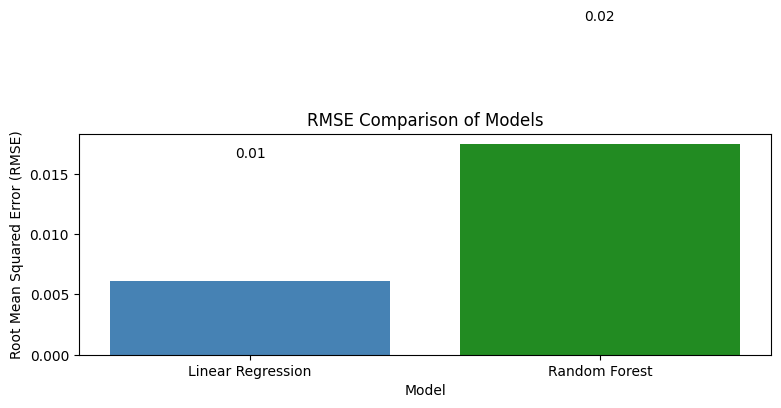

In [80]:
import matplotlib.pyplot as plt

# Replace with your actual RMSE values
rmse_scores = {
    'Linear Regression': lr_rmse,
    'Random Forest': rf_rmse
}

# Extract names and scores
model_names = list(rmse_scores.keys())
rmse_values = list(rmse_scores.values())

# Plot the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, rmse_values, color=['steelblue', 'forestgreen'])
plt.title('RMSE Comparison of Models')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xlabel('Model')

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Features Importance Bar 

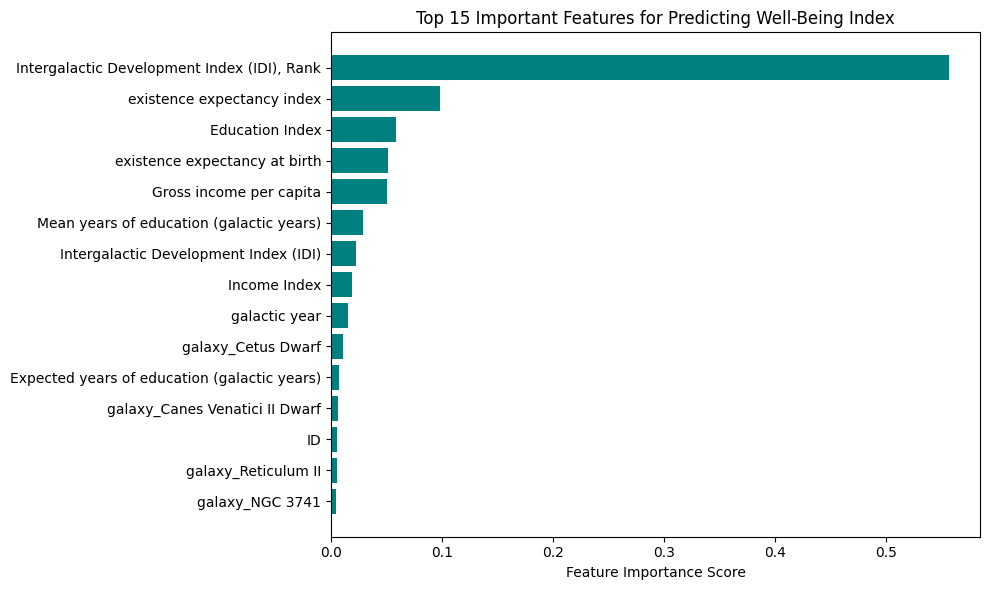

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_model.feature_importances_

# Get feature names from your X_train DataFrame
feature_names = X_train.columns

# Create a DataFrame for sorting and plotting
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][:15][::-1], feature_imp_df['Importance'][:15][::-1], color='teal')
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Important Features for Predicting Well-Being Index')
plt.tight_layout()
plt.show()
